In [4]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=OCZArGmzfdCf4UdaM8LMnxeBjZNt65&access_type=offline&code_challenge=q3p0fmG8w0-UmNFz6LCjY_vV7La24i7fXFV-ufj5BYM&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [1]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/21 16:16:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/21 16:16:30 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/21 16:16:30 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [3]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")

l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet")

# With measurments data

In [2]:
combined_evidence = session.spark.read.csv("./data/combined_evidence_with_measurements.csv", header=True, inferSchema=True)

In [5]:
#combined_evidence.write.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/combined_evidence_with_measurements.parquet", mode="overwrite")

In [4]:
combined_evidence.groupBy("source").count().show()

+-----------------+------+
|           source| count|
+-----------------+------+
|     all_diseases| 36858|
|      gene_burden|  6857|
|             omim|  6596|
|         orphanet|  6192|
| all_measurements|150360|
|           ChEMBL| 25234|
|    cancer_ChEMBL|  8811|
|        gwas_eQTL| 12343|
|    gwas_with_pav|  5441|
|           molQTL| 17755|
|non_cancer_ChEMBL| 16423|
+-----------------+------+



In [6]:
combined_evidence.select("targetId").distinct().count()

18809

In [7]:
combined_evidence.filter(~(f.col("source")=="molQTL")).select("targetId").distinct().count()

16479

In [8]:
combined_evidence.filter(f.col("source").isin(["all_diseases","all_measurements"])).select("targetId").distinct().count()

15641

In [9]:
combined_evidence.filter(f.col("source").isin(["omim"])).select("targetId").distinct().count()

4182

In [10]:
target=session.spark.read.csv("./data/target_with_constraints_2509.csv",header=True, inferSchema=True)
target.count()

20083

# Upset plot

In [7]:
combined_evidence_upset_plot=combined_evidence.filter((f.col("source").isin(["all_diseases","gene_burden","all_measurements","molQTL","orphanet","omim"])))

In [8]:
combined_evidence_upset_plot=combined_evidence_upset_plot.select("targetId","source").distinct()

In [9]:
combined_evidence_upset_plot.groupBy("source").count().show()

+----------------+-----+
|          source|count|
+----------------+-----+
|    all_diseases| 8285|
|     gene_burden| 1677|
|            omim| 4182|
|          molQTL|17755|
|        orphanet| 3814|
|all_measurements|15160|
+----------------+-----+



In [10]:
import pandas as pd
from upsetplot import from_contents, plot
import matplotlib.pyplot as plt

In [11]:
combined_evidence_upset_plot=combined_evidence_upset_plot.filter(f.col("source").isin(["all_diseases","all_measurements","molQTL"]))

In [15]:
combined_evidence_upset_plot.groupBy("source").count().show()

+----------------+-----+
|          source|count|
+----------------+-----+
|    all_diseases| 8285|
|          molQTL|17755|
|all_measurements|15160|
+----------------+-----+



In [14]:
combined_evidence_upset_plot.select("targetId").distinct().count()

18641

In [21]:
combined_evidence_upset_plot = combined_evidence_upset_plot.replace({
    'all_diseases': 'Diseases',
    'all_measurements': 'Measurements'
}, subset=['source'])

Sources found: ['Diseases' 'Measurements' 'molQTL']


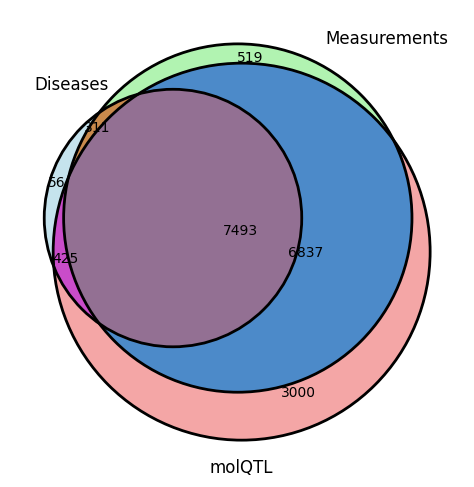

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import numpy as np

# Assuming you have combined_evidence_upset_plot_pd with 'source' and 'targetId' columns
# First, create sets for each source
combined_evidence_upset_plot_pd = combined_evidence_upset_plot.toPandas()
sources = combined_evidence_upset_plot_pd['source'].unique()
print("Sources found:", sources)

# Create gene sets for each source
gene_sets = {}
for source in sources:
    gene_sets[source] = set(combined_evidence_upset_plot_pd[
        combined_evidence_upset_plot_pd['source'] == source
    ]['targetId'].tolist())

# For a 3-way Venn diagram, you need exactly 3 sets
source_list = list(gene_sets.keys())
if len(source_list) == 3:
    set1, set2, set3 = gene_sets[source_list[0]], gene_sets[source_list[1]], gene_sets[source_list[2]]
    
    # Calculate set sizes and overlaps
    set_sizes = (
        len(set1 - set2 - set3),           # Only set1
        len(set2 - set1 - set3),           # Only set2  
        len(set1 & set2 - set3),           # set1 & set2, not set3
        len(set3 - set1 - set2),           # Only set3
        len(set1 & set3 - set2),           # set1 & set3, not set2
        len(set2 & set3 - set1),           # set2 & set3, not set1
        len(set1 & set2 & set3)            # All three sets
    )
    
    # Create the Venn diagram
    plt.figure(figsize=(5, 5))
    
    # Create venn diagram with proportional circles
    venn = venn3(subsets=set_sizes, 
                 set_labels=source_list,
                 alpha=0.7)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    if venn.get_patch_by_id('100'):
        venn.get_patch_by_id('100').set_color(colors[0])
    if venn.get_patch_by_id('010'):
        venn.get_patch_by_id('010').set_color(colors[1])
    if venn.get_patch_by_id('001'):
        venn.get_patch_by_id('001').set_color(colors[2])
    
    # Add circles with proportional sizes
    venn3_circles(subsets=set_sizes, linewidth=2)
    
    plt.tight_layout()
    plt.show()

Sources found: ['Diseases' 'Measurements' 'molQTL']


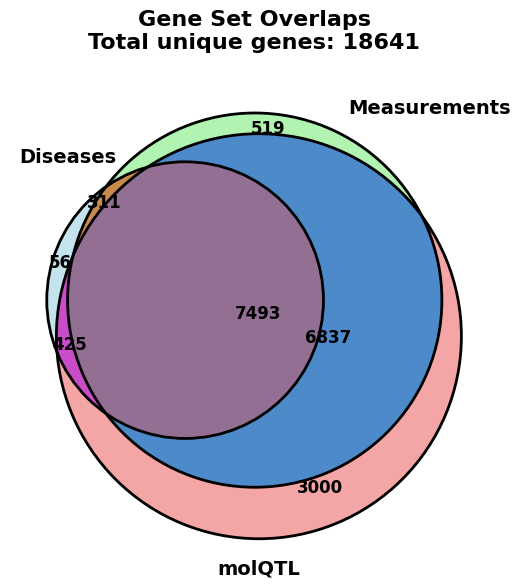

In [37]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import numpy as np

# Assuming you have combined_evidence_upset_plot_pd with 'source' and 'targetId' columns
# First, create sets for each source
combined_evidence_upset_plot_pd = combined_evidence_upset_plot.toPandas()
sources = combined_evidence_upset_plot_pd['source'].unique()
print("Sources found:", sources)

# Create gene sets for each source
gene_sets = {}
for source in sources:
    gene_sets[source] = set(combined_evidence_upset_plot_pd[
        combined_evidence_upset_plot_pd['source'] == source
    ]['targetId'].tolist())

# For a 3-way Venn diagram, you need exactly 3 sets
source_list = list(gene_sets.keys())
if len(source_list) == 3:
    set1, set2, set3 = gene_sets[source_list[0]], gene_sets[source_list[1]], gene_sets[source_list[2]]
    
    # Calculate set sizes and overlaps
    set_sizes = (
        len(set1 - set2 - set3),           # Only set1
        len(set2 - set1 - set3),           # Only set2  
        len(set1 & set2 - set3),           # set1 & set2, not set3
        len(set3 - set1 - set2),           # Only set3
        len(set1 & set3 - set2),           # set1 & set3, not set2
        len(set2 & set3 - set1),           # set2 & set3, not set1
        len(set1 & set2 & set3)            # All three sets
    )
    
    # Create the Venn diagram
    plt.figure(figsize=(6, 6))
    
    # Create venn diagram with proportional circles
    venn = venn3(subsets=set_sizes, 
                 set_labels=source_list,
                 alpha=0.7)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    if venn.get_patch_by_id('100'):
        venn.get_patch_by_id('100').set_color(colors[0])
    if venn.get_patch_by_id('010'):
        venn.get_patch_by_id('010').set_color(colors[1])
    if venn.get_patch_by_id('001'):
        venn.get_patch_by_id('001').set_color(colors[2])
    
    # Customize the labels inside the diagram
    # The subset_labels correspond to the 7 regions in the order defined in set_sizes
    if venn.subset_labels[0]:  # Only set1
        venn.subset_labels[0].set_text(f'{set_sizes[0]}')
        venn.subset_labels[0].set_fontsize(12)
        venn.subset_labels[0].set_fontweight('bold')
    
    if venn.subset_labels[1]:  # Only set2
        venn.subset_labels[1].set_text(f'{set_sizes[1]}')
        venn.subset_labels[1].set_fontsize(12)
        venn.subset_labels[1].set_fontweight('bold')
    
    if venn.subset_labels[2]:  # set1 & set2, not set3
        venn.subset_labels[2].set_text(f'{set_sizes[2]}')
        venn.subset_labels[2].set_fontsize(12)
        venn.subset_labels[2].set_fontweight('bold')
    
    if venn.subset_labels[3]:  # Only set3
        venn.subset_labels[3].set_text(f'{set_sizes[3]}')
        venn.subset_labels[3].set_fontsize(12)
        venn.subset_labels[3].set_fontweight('bold')
    
    if venn.subset_labels[4]:  # set1 & set3, not set2
        venn.subset_labels[4].set_text(f'{set_sizes[4]}')
        venn.subset_labels[4].set_fontsize(12)
        venn.subset_labels[4].set_fontweight('bold')
    
    if venn.subset_labels[5]:  # set2 & set3, not set1
        venn.subset_labels[5].set_text(f'{set_sizes[5]}')
        venn.subset_labels[5].set_fontsize(12)
        venn.subset_labels[5].set_fontweight('bold')
    
    if venn.subset_labels[6]:  # All three sets
        venn.subset_labels[6].set_text(f'{set_sizes[6]}')
        venn.subset_labels[6].set_fontsize(12)
        venn.subset_labels[6].set_fontweight('bold')
  # Highlight the intersection
    
    # Customize set labels (outside the circles)
    for label in venn.set_labels:
        if label:
            label.set_fontsize(14)
            label.set_fontweight('bold')
    
    # Add circles with proportional sizes
    venn3_circles(subsets=set_sizes, linewidth=2)
    
    # Add title with summary statistics
    total_genes = len(set1.union(set2, set3))
    plt.title(f'Gene Set Overlaps\nTotal unique genes: {total_genes}', 
              fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

Sources found: ['Diseases' 'Measurements' 'molQTL']


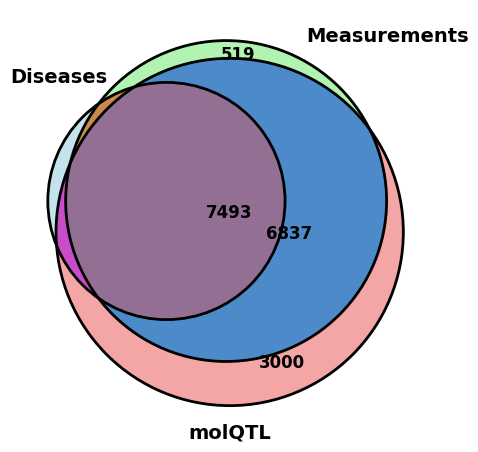


All overlap statistics:
Only Diseases: 56 (hidden)
Only Measurements: 519 (shown)
Only molQTL: 3000 (shown)
Diseases & Measurements only: 311 (hidden)
Diseases & molQTL only: 425 (hidden)
Measurements & molQTL only: 6837 (shown)
All three: 7493 (shown)


25/10/07 01:22:12 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 956599 ms exceeds timeout 120000 ms
25/10/07 01:22:12 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/07 01:22:16 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [40]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import numpy as np

# Assuming you have combined_evidence_upset_plot_pd with 'source' and 'targetId' columns
# First, create sets for each source
combined_evidence_upset_plot_pd = combined_evidence_upset_plot.toPandas()
sources = combined_evidence_upset_plot_pd['source'].unique()
print("Sources found:", sources)

# Create gene sets for each source
gene_sets = {}
for source in sources:
    gene_sets[source] = set(combined_evidence_upset_plot_pd[
        combined_evidence_upset_plot_pd['source'] == source
    ]['targetId'].tolist())

# For a 3-way Venn diagram, you need exactly 3 sets
source_list = list(gene_sets.keys())
if len(source_list) == 3:
    set1, set2, set3 = gene_sets[source_list[0]], gene_sets[source_list[1]], gene_sets[source_list[2]]
    
    # Calculate set sizes and overlaps
    set_sizes = (
        len(set1 - set2 - set3),           # Only set1
        len(set2 - set1 - set3),           # Only set2  
        len(set1 & set2 - set3),           # set1 & set2, not set3
        len(set3 - set1 - set2),           # Only set3
        len(set1 & set3 - set2),           # set1 & set3, not set2
        len(set2 & set3 - set1),           # set2 & set3, not set1
        len(set1 & set2 & set3)            # All three sets
    )
    
    # Create the Venn diagram
    plt.figure(figsize=(5, 5))
    
    # Create venn diagram with proportional circles
    venn = venn3(subsets=set_sizes, 
                 set_labels=source_list,
                 alpha=0.7)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    if venn.get_patch_by_id('100'):
        venn.get_patch_by_id('100').set_color(colors[0])
    if venn.get_patch_by_id('010'):
        venn.get_patch_by_id('010').set_color(colors[1])
    if venn.get_patch_by_id('001'):
        venn.get_patch_by_id('001').set_color(colors[2])
    
    # Customize the labels inside the diagram - only show if >= 600
    min_size_threshold = 500
    
    if venn.subset_labels[0] and set_sizes[0] >= min_size_threshold:  # Only set1
        venn.subset_labels[0].set_text(f'{set_sizes[0]}')
        venn.subset_labels[0].set_fontsize(12)
        venn.subset_labels[0].set_fontweight('bold')
    elif venn.subset_labels[0]:
        venn.subset_labels[0].set_text('')  # Hide label if below threshold
    
    if venn.subset_labels[1] and set_sizes[1] >= min_size_threshold:  # Only set2
        venn.subset_labels[1].set_text(f'{set_sizes[1]}')
        venn.subset_labels[1].set_fontsize(12)
        venn.subset_labels[1].set_fontweight('bold')
    elif venn.subset_labels[1]:
        venn.subset_labels[1].set_text('')
    
    if venn.subset_labels[2] and set_sizes[2] >= min_size_threshold:  # set1 & set2, not set3
        venn.subset_labels[2].set_text(f'{set_sizes[2]}')
        venn.subset_labels[2].set_fontsize(12)
        venn.subset_labels[2].set_fontweight('bold')
    elif venn.subset_labels[2]:
        venn.subset_labels[2].set_text('')
    
    if venn.subset_labels[3] and set_sizes[3] >= min_size_threshold:  # Only set3
        venn.subset_labels[3].set_text(f'{set_sizes[3]}')
        venn.subset_labels[3].set_fontsize(12)
        venn.subset_labels[3].set_fontweight('bold')
    elif venn.subset_labels[3]:
        venn.subset_labels[3].set_text('')
    
    if venn.subset_labels[4] and set_sizes[4] >= min_size_threshold:  # set1 & set3, not set2
        venn.subset_labels[4].set_text(f'{set_sizes[4]}')
        venn.subset_labels[4].set_fontsize(12)
        venn.subset_labels[4].set_fontweight('bold')
    elif venn.subset_labels[4]:
        venn.subset_labels[4].set_text('')
    
    if venn.subset_labels[5] and set_sizes[5] >= min_size_threshold:  # set2 & set3, not set1
        venn.subset_labels[5].set_text(f'{set_sizes[5]}')
        venn.subset_labels[5].set_fontsize(12)
        venn.subset_labels[5].set_fontweight('bold')
    elif venn.subset_labels[5]:
        venn.subset_labels[5].set_text('')
    
    if venn.subset_labels[6] and set_sizes[6] >= min_size_threshold:  # All three sets
        venn.subset_labels[6].set_text(f'{set_sizes[6]}')
        venn.subset_labels[6].set_fontsize(12)
        venn.subset_labels[6].set_fontweight('bold')
    elif venn.subset_labels[6]:
        venn.subset_labels[6].set_text('')
    
    # Customize set labels (outside the circles)
    for label in venn.set_labels:
        if label:
            label.set_fontsize(14)
            label.set_fontweight('bold')
    
    # Add circles with proportional sizes
    venn3_circles(subsets=set_sizes, linewidth=2)
    
    # Add title with summary statistics
    total_genes = len(set1.union(set2, set3))
    #plt.title(f'Gene Set Overlaps\nTotal unique genes: {total_genes}', 
    #          fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print all statistics (including those not shown)
    print(f"\nAll overlap statistics:")
    print(f"Only {source_list[0]}: {set_sizes[0]} {'(shown)' if set_sizes[0] >= min_size_threshold else '(hidden)'}")
    print(f"Only {source_list[1]}: {set_sizes[1]} {'(shown)' if set_sizes[1] >= min_size_threshold else '(hidden)'}")
    print(f"Only {source_list[2]}: {set_sizes[3]} {'(shown)' if set_sizes[3] >= min_size_threshold else '(hidden)'}")
    print(f"{source_list[0]} & {source_list[1]} only: {set_sizes[2]} {'(shown)' if set_sizes[2] >= min_size_threshold else '(hidden)'}")
    print(f"{source_list[0]} & {source_list[2]} only: {set_sizes[4]} {'(shown)' if set_sizes[4] >= min_size_threshold else '(hidden)'}")
    print(f"{source_list[1]} & {source_list[2]} only: {set_sizes[5]} {'(shown)' if set_sizes[5] >= min_size_threshold else '(hidden)'}")
    print(f"All three: {set_sizes[6]} {'(shown)' if set_sizes[6] >= min_size_threshold else '(hidden)'}")

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/var/folders/p5/4t9crp1563l792qz8xz_3x5h00

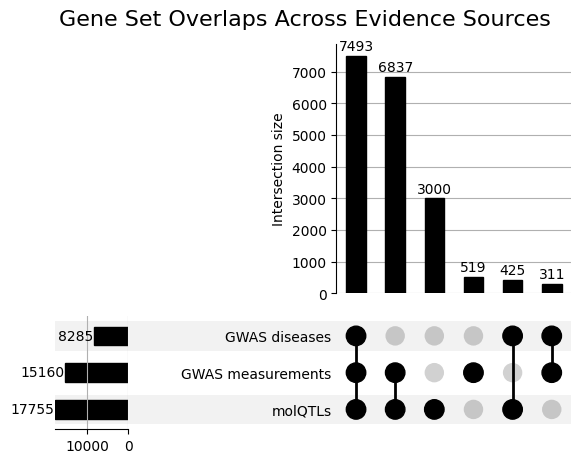

Total unique genes across all sources: 18641
Number of intersections: 18641


In [12]:
# Convert to pandas and create upset plot with cleaner labels
combined_evidence_upset_plot_pd = combined_evidence_upset_plot.toPandas()

# Create mapping for cleaner names
source_mapping = {
    'all_diseases': 'GWAS diseases',
    'gene_burden': 'Gene-based analysis',
    'omim': 'OMIM',
    'molQTL': 'molQTLs',
    'orphanet': 'Orphanet',
    'all_measurements': 'GWAS measurements',
    'ChEMBL': 'ChEMBL'
}

# Apply mapping
combined_evidence_upset_plot_pd['source_clean'] = combined_evidence_upset_plot_pd['source'].map(source_mapping)

# Create gene sets with clean names
gene_sets = {}
for source in combined_evidence_upset_plot_pd['source_clean'].unique():
    gene_sets[source] = set(combined_evidence_upset_plot_pd[
        combined_evidence_upset_plot_pd['source_clean'] == source
    ]['targetId'].tolist())

# Create upset plot
upset_data = from_contents(gene_sets)

# Create the plot with custom styling
fig = plt.figure(figsize=(14, 10))
plot(upset_data, 
     fig=fig, 
     show_counts=True, 
     sort_by='cardinality',
     sort_categories_by='cardinality',
     element_size=40,
     intersection_plot_elements=6,
     min_subset_size=70
     )

plt.suptitle('Gene Set Overlaps Across Evidence Sources', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

# Print intersection statistics
print(f"Total unique genes across all sources: {len(set.union(*gene_sets.values()))}")
print(f"Number of intersections: {len(upset_data)}")

In [206]:
combined_evidence_upset_plot.select("targetId").distinct().count()

18799

In [207]:
combined_evidence_upset_plot.filter(~(f.col("source")=="molQTL")).select("targetId").distinct().count()

16393

# Load data without measuments and preparing data

In [4]:
combined_evidence = session.spark.read.csv("./data/combined_evidence_without_measurements.csv", header=True, inferSchema=True)

In [5]:
combined_evidence.select("targetId").distinct().count()

11022

In [6]:
target=session.spark.read.csv("./data/target_with_constraints_2509.csv",header=True, inferSchema=True)
target.count()

20083

In [ ]:
#pleiotropy_combined_evidence = combined_evidence.groupBy("targetId").agg(
#    f.countDistinct("diseaseId").alias("unique_disease_count")
#).cache()
#pleiotropy_combined_evidence.count()

11022

In [7]:
pleiotropy_combined_evidence_gwas_only = combined_evidence.filter(f.col("source") == "all_diseases").groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_combined_evidence_gwas_only.count()

8285

In [8]:
pleiotropy_combined_evidence_gwas_only.toPandas().to_csv("./data/pleiotropy_combined_evidence_gwas_only.csv", index=False)

In [9]:
pleiotropy_combined_evidence = combined_evidence.filter((f.col("source").isin(["all_diseases","gene_burden","orphanet","omim"]))).groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_combined_evidence.count()

10734

In [10]:
pleiotropy_combined_evidence.toPandas().to_csv("./data/pleiotropy_combined_evidence.csv", index=False)

# Upset plot for diseases

In [212]:
combined_evidence_upset_plot=combined_evidence.filter((f.col("source").isin(["all_diseases","gene_burden","orphanet","omim"])))
combined_evidence_upset_plot=combined_evidence_upset_plot.select("targetId","source").distinct()

In [213]:
combined_evidence_upset_plot.groupBy("source").count().show()

+------------+-----+
|      source|count|
+------------+-----+
|all_diseases| 8285|
| gene_burden|  557|
|        omim| 4182|
|    orphanet| 3814|
+------------+-----+



/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/var/folders/p5/4t9crp1563l792qz8xz_3x5h00

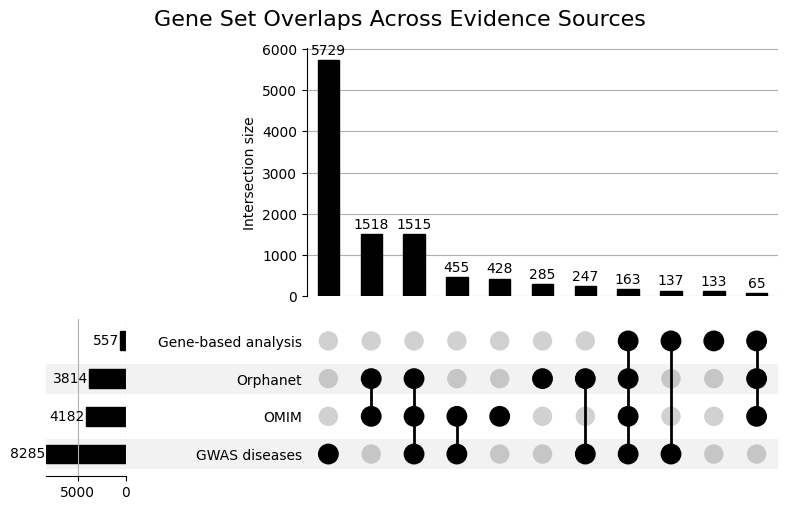

Total unique genes across all sources: 10734
Number of intersections: 10734


In [215]:
# Convert to pandas and create upset plot with cleaner labels
combined_evidence_upset_plot_pd = combined_evidence_upset_plot.toPandas()

# Create mapping for cleaner names
source_mapping = {
    'all_diseases': 'GWAS diseases',
    'gene_burden': 'Gene-based analysis',
    'omim': 'OMIM',
    'orphanet': 'Orphanet',
    'ChEMBL': 'ChEMBL'
}

# Apply mapping
combined_evidence_upset_plot_pd['source_clean'] = combined_evidence_upset_plot_pd['source'].map(source_mapping)

# Create gene sets with clean names
gene_sets = {}
for source in combined_evidence_upset_plot_pd['source_clean'].unique():
    gene_sets[source] = set(combined_evidence_upset_plot_pd[
        combined_evidence_upset_plot_pd['source_clean'] == source
    ]['targetId'].tolist())

# Create upset plot
upset_data = from_contents(gene_sets)

# Create the plot with custom styling
fig = plt.figure(figsize=(14, 10))
plot(upset_data, 
     fig=fig, 
     show_counts=True, 
     sort_by='cardinality',
     sort_categories_by='cardinality',
     element_size=40,
     intersection_plot_elements=6,
     min_subset_size=30
     )

plt.suptitle('Gene Set Overlaps Across Evidence Sources', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

# Print intersection statistics
print(f"Total unique genes across all sources: {len(set.union(*gene_sets.values()))}")
print(f"Number of intersections: {len(upset_data)}")

In [216]:
combined_evidence_upset_plot.select("targetId").distinct().count()

10734

# Comparion of pleyitropy between GWAS and all geneti evidence sources

In [9]:
combined_evidence.groupBy("source").count().show()

+-----------------+-----+
|           source|count|
+-----------------+-----+
|     all_diseases|36858|
|    cancer_ChEMBL| 8811|
|      gene_burden| 1777|
|             omim| 6596|
|        gwas_eQTL|12343|
|    gwas_with_pav| 5441|
|         orphanet| 6192|
|           ChEMBL|25229|
|non_cancer_ChEMBL|16418|
+-----------------+-----+



In [218]:
pleiotropy_combined_evidence = combined_evidence.filter(~(f.col("source").isin(["ChEMBL","non_cancer_ChEMBL","cancer_ChEMBL"]))).groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_combined_evidence.count()

25/09/19 22:57:45 WARN CacheManager: Asked to cache already cached data.


10734

In [219]:
pleiotropy_combined_evidence_gwas_only = combined_evidence.filter(f.col("source") == "all_diseases").groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_combined_evidence_gwas_only.count()

25/09/19 22:58:04 WARN CacheManager: Asked to cache already cached data.


8285

In [220]:
combined_pleiotropy = (
    pleiotropy_combined_evidence
    .join(
        pleiotropy_combined_evidence_gwas_only.withColumnRenamed(
            "unique_disease_count", "gwas_only_disease_count"
        ),
        on="targetId",
        how="full_outer"
    )
    .fillna(0, subset=["unique_disease_count", "gwas_only_disease_count"])
)

combined_pleiotropy.count()

10734

In [221]:
combined_pleiotropy.show(1)

+---------------+--------------------+-----------------------+
|       targetId|unique_disease_count|gwas_only_disease_count|
+---------------+--------------------+-----------------------+
|ENSG00000059588|                   1|                      1|
+---------------+--------------------+-----------------------+
only showing top 1 row



In [222]:
# Pearson correlation between two columns
correlation = combined_pleiotropy.stat.corr("unique_disease_count", "gwas_only_disease_count")
print(f"Pearson correlation: {correlation}")

Pearson correlation: 0.9294964173901605


In [223]:
# Show top targets with both all-sources and GWAS-only pleiotropy
top_targets_detailed = (
    combined_pleiotropy
    .orderBy(f.desc("unique_disease_count"))
    .select("targetId", "unique_disease_count", "gwas_only_disease_count")
    .limit(20)
)

top_targets_detailed.show()

+---------------+--------------------+-----------------------+
|       targetId|unique_disease_count|gwas_only_disease_count|
+---------------+--------------------+-----------------------+
|ENSG00000147883|                 148|                    148|
|ENSG00000140718|                 128|                    126|
|ENSG00000168769|                 114|                     34|
|ENSG00000130203|                 111|                    107|
|ENSG00000175164|                 105|                    105|
|ENSG00000171456|                  93|                      5|
|ENSG00000164362|                  93|                     84|
|ENSG00000111252|                  88|                     87|
|ENSG00000166949|                  86|                     82|
|ENSG00000183765|                  84|                     60|
|ENSG00000148737|                  76|                     75|
|ENSG00000134242|                  73|                     71|
|ENSG00000139618|                  71|                 

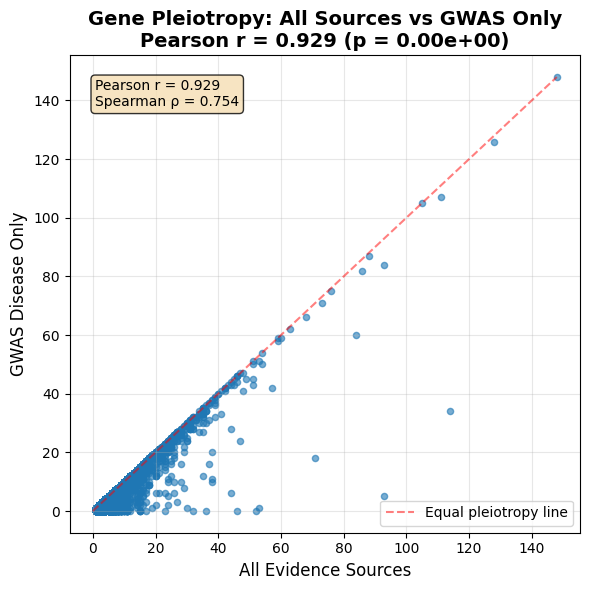

Pearson correlation: 0.9295, p-value: 0.0000e+00
Spearman correlation: 0.7537, p-value: 0.0000e+00
Sample size: 10734


In [230]:
# Convert Spark DataFrame to pandas if needed
combined_pleiotropy_pd = combined_pleiotropy.toPandas()

# Calculate correlation
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Calculate both Pearson and Spearman correlations
pearson_corr, pearson_p = pearsonr(combined_pleiotropy_pd['unique_disease_count'], 
                                   combined_pleiotropy_pd['gwas_only_disease_count'])
spearman_corr, spearman_p = spearmanr(combined_pleiotropy_pd['unique_disease_count'], 
                                      combined_pleiotropy_pd['gwas_only_disease_count'])

# Create scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(combined_pleiotropy_pd['unique_disease_count'], 
            combined_pleiotropy_pd['gwas_only_disease_count'], 
            alpha=0.6, s=20)

plt.xlabel('All Evidence Sources', fontsize=12)
plt.ylabel('GWAS Disease Only', fontsize=12)

# Add correlation to title
plt.title(f'Gene Pleiotropy: All Sources vs GWAS Only\n' +
          f'Pearson r = {pearson_corr:.3f} (p = {pearson_p:.2e})', 
          fontsize=14, fontweight='bold')

# Add diagonal reference line
max_val = max(combined_pleiotropy_pd['unique_disease_count'].max(), 
              combined_pleiotropy_pd['gwas_only_disease_count'].max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal pleiotropy line')

# Add correlation text box in the plot
textstr = f'Pearson r = {pearson_corr:.3f}\nSpearman ρ = {spearman_corr:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print correlation statistics
print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")
print(f"Sample size: {len(combined_pleiotropy_pd)}")

# Plots - preaparing data

In [107]:
target.show(1)

+---------------+--------------+----------+----------+----------+
|       targetId|       biotype|syn_constr|mis_constr|lof_constr|
+---------------+--------------+----------+----------+----------+
|ENSG00000000003|protein_coding|      NULL|      NULL|      NULL|
+---------------+--------------+----------+----------+----------+
only showing top 1 row



In [108]:
essential_genes = session.spark.read.parquet("gs://ot-team/irene/cautionary_targets/annotated_targets_wide.parquet")

In [109]:
essential_genes.show(1)

+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|       targetId|pharmacogene|liable_target|withdrawn_drug|essential_gene|mouse_ko_mortality|dd_related|cancer_driver_gene|trial_safety_concern|drug_target|non_oncology_drug_target|oncology_drug_target|inComplex|selectiveGene|non_essential|distant_ortholog|hc_paralog|
+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|ENSG00000083454|           0|            1|             0|             0|                 0|         0|                 0|                   0|          0|                       0|            

In [110]:
#essential_genes = session.spark.read.parquet("gs://ot-team/irene/cautionary_targets/cautionary_targets_wide.parquet/")

In [111]:
#essential_genes.count()

In [112]:
essential_genes = essential_genes.fillna(0)

In [113]:
essential_genes.show(1)

+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|       targetId|pharmacogene|liable_target|withdrawn_drug|essential_gene|mouse_ko_mortality|dd_related|cancer_driver_gene|trial_safety_concern|drug_target|non_oncology_drug_target|oncology_drug_target|inComplex|selectiveGene|non_essential|distant_ortholog|hc_paralog|
+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|ENSG00000083454|           0|            1|             0|             0|                 0|         0|                 0|                   0|          0|                       0|            

In [114]:
# Define the columns to melt (exclude targetId)
value_columns = [
    'pharmacogene', 'liable_target', 'withdrawn_drug', 'essential_gene',
    'mouse_ko_mortality', 'dd_related', 'cancer_driver_gene', 
    'trial_safety_concern',"inComplex","selectiveGene","non_essential",
    "hc_paralog","distant_ortholog"
]

# Melt the DataFrame
essential_genes_long = essential_genes.select(
    f.col("targetId"),
    *[f.col(c) for c in value_columns]
).melt(
    ids=["targetId"],
    values=value_columns,
    variableColumnName="category",
    valueColumnName="value"
)

essential_genes_long.count()

109850

In [115]:
essential_genes_long.show(1)

+---------------+------------+-----+
|       targetId|    category|value|
+---------------+------------+-----+
|ENSG00000083454|pharmacogene|    0|
+---------------+------------+-----+
only showing top 1 row



In [116]:
essential_genes_long.groupBy("category").count().show(20)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|          hc_paralog| 8450|
|    distant_ortholog| 8450|
|           inComplex| 8450|
|  cancer_driver_gene| 8450|
|      withdrawn_drug| 8450|
|       selectiveGene| 8450|
|      essential_gene| 8450|
|       liable_target| 8450|
|          dd_related| 8450|
|        pharmacogene| 8450|
|trial_safety_concern| 8450|
|  mouse_ko_mortality| 8450|
|       non_essential| 8450|
+--------------------+-----+



In [117]:
essential_genes_long.groupBy("value").count().show(20)

+-----+-----+
|value|count|
+-----+-----+
|    1|12819|
|    0|97031|
+-----+-----+



In [118]:
essential_genes_long=essential_genes_long.filter(f.col("value")==1).drop("value")

In [119]:
essential_genes_long.groupBy("category").count().show(20)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|          hc_paralog| 1588|
|    distant_ortholog|  831|
|           inComplex| 3566|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|       selectiveGene|  930|
|      essential_gene| 1489|
|       liable_target|  214|
|          dd_related|  866|
|        pharmacogene|  543|
|trial_safety_concern|  448|
|  mouse_ko_mortality| 1038|
|       non_essential|  772|
+--------------------+-----+



In [120]:
essential_genes_long.show(1)

+---------------+-------------+
|       targetId|     category|
+---------------+-------------+
|ENSG00000083454|liable_target|
+---------------+-------------+
only showing top 1 row



In [121]:
essential_genes_long=essential_genes_long.join(target.select("targetId"),on="targetId",how="inner")

In [122]:
essential_genes_long.groupBy("category").count().show(20)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|          hc_paralog| 1587|
|    distant_ortholog|  830|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|       selectiveGene|  930|
|      essential_gene| 1489|
|       liable_target|  214|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
|  mouse_ko_mortality| 1022|
|       non_essential|  766|
+--------------------+-----+



In [123]:
essential_genes_long=essential_genes_long.withColumnRenamed("category","source")

In [124]:
essential_genes_long.show(1)

+---------------+-------------+
|       targetId|       source|
+---------------+-------------+
|ENSG00000083454|liable_target|
+---------------+-------------+
only showing top 1 row



In [125]:
essential_genes_long.write \
    .mode("overwrite") \
    .parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/essential_genes_list_long.parquet")

In [126]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|orphanet|
+---------------+--------+
only showing top 1 row



In [127]:
combined_evidence_all=combined_evidence.select("targetId","source").unionByName(essential_genes_long).distinct().cache()
combined_evidence_all.count()

60511

In [128]:
all_genes=target.select("targetId").distinct()
all_genes=all_genes.withColumn("source",f.lit("All genes"))
combined_evidence_all=combined_evidence_all.unionByName(all_genes).distinct().cache()

In [129]:
combined_evidence_all.groupBy("source").count().show()

+------------------+-----+
|            source|count|
+------------------+-----+
|      all_diseases| 8285|
|        hc_paralog| 4173|
|  distant_ortholog|  830|
|     cancer_ChEMBL|  649|
|       gene_burden|  557|
|              omim| 4182|
|         inComplex| 3530|
| non_cancer_ChEMBL|  958|
|     selectiveGene|  930|
|    essential_gene| 1489|
|         gwas_eQTL| 3945|
|     gwas_with_pav| 1574|
|     liable_target|  214|
|          orphanet| 3814|
|            ChEMBL| 1137|
|        dd_related|  861|
|      pharmacogene|  538|
|mouse_ko_mortality| 1022|
|         All genes|20083|
|     non_essential|  766|
+------------------+-----+
only showing top 20 rows



In [130]:
combined_evidence_all.toPandas().to_csv("./data/combined_evidence_for_constrain_plot.csv", index=False)

# Plotting - pleiotropy_combined_evidence

In [39]:
target=session.spark.read.csv("./data/target_with_constraints_2509.csv",header=True, inferSchema=True)
target.count()

20083

In [40]:
pleiotropy_combined_evidence = session.spark.read.csv("./data/pleiotropy_combined_evidence.csv",header=True, inferSchema=True)
pleiotropy_combined_evidence.count()

10734

In [41]:
pleiotropy_combined_evidence.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000196950|                   2|
+---------------+--------------------+
only showing top 1 row



In [42]:
combined_evidence=session.spark.read.csv("./data/combined_evidence_for_constrain_plot.csv", header=True, inferSchema=True)

In [64]:
combined_evidence.count()

50282

In [65]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
|  mouse_ko_mortality| 1022|
|           All genes|20083|
+--------------------+-----+



In [66]:
# Create mapping dictionary
category_mapping = {
    'all_diseases': 'GWAS',
    'cancer_ChEMBL': 'Cancer ChEMBL',
    'gene_burden': 'Gene-based analysis',
    'omim': 'OMIM',
    'cancer_driver_gene': 'Cancer Driver (COSMIC)',
    'withdrawn_drug': 'Withdrawn Drug',
    'non_cancer_ChEMBL': 'Non-Cancer ChEMBL',
    'essential_gene': 'Essential Gene (DepMap)',
    'gwas_eQTL': 'GWAS with eQTL evidence',
    'gwas_with_pav': 'GWAS with PAV evidence',
    'liable_target': 'Known safety events',
    'orphanet': 'Orphanet',
    'ChEMBL': 'ChEMBL',
    'dd_related': 'DD panel (gene2phenotype)',
    'pharmacogene': 'Pharmacogenetics - Toxicity',
    'trial_safety_concern': 'Trial Safety',
    'mouse_ko_mortality': 'Mouse KO Mortality',
    'All genes': 'All protein-coding genes'
}

# Apply the mapping
from pyspark.sql.functions import col
combined_evidence = combined_evidence.replace(category_mapping, subset=['source'])

In [67]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|            Orphanet| 3814|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
|GWAS with eQTL ev...| 3945|
|GWAS with PAV evi...| 1574|
+--------------------+-----+



In [68]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|Orphanet|
+---------------+--------+
only showing top 1 row



In [69]:
combined_evidence.count()

50282

In [70]:
combined_evidence = (
    combined_evidence
    .join(pleiotropy_combined_evidence_gwas_only, on="targetId", how="left")
    .fillna(0, subset=["unique_disease_count"])
    .cache()
)

combined_evidence.count()

25/09/19 23:30:03 WARN CacheManager: Asked to cache already cached data.


50282

In [71]:
combined_evidence.show(1)

+---------------+--------+--------------------+
|       targetId|  source|unique_disease_count|
+---------------+--------+--------------------+
|ENSG00000121075|Orphanet|                   2|
+---------------+--------+--------------------+
only showing top 1 row



In [72]:
combined_evidence = (
    combined_evidence
    .join(target.select("targetId","lof_constr"), on="targetId", how="left")
    .cache()
)

combined_evidence.count()

25/09/19 23:30:04 WARN CacheManager: Asked to cache already cached data.


50282

In [73]:
combined_evidence.show(1)

+---------------+--------+--------------------+----------+
|       targetId|  source|unique_disease_count|lof_constr|
+---------------+--------+--------------------+----------+
|ENSG00000121075|Orphanet|                   2|    -0.379|
+---------------+--------+--------------------+----------+
only showing top 1 row



In [74]:
combined_evidence=combined_evidence.toPandas()

In [75]:
combined_evidence = combined_evidence.dropna(subset=['lof_constr'])

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate summary statistics by source
summary_stats = combined_evidence.groupby('source').agg({
    'unique_disease_count': ['mean', 'std', 'count'],
    'lof_constr': ['mean', 'std', 'count']
}).reset_index()

# Flatten column names
summary_stats.columns = ['source', 'pleiotropy_mean', 'pleiotropy_std', 'pleiotropy_count',
                         'constraint_mean', 'constraint_std', 'constraint_count']

# Calculate 95% CI (1.96 * SE)
summary_stats['pleiotropy_se'] = summary_stats['pleiotropy_std'] / np.sqrt(summary_stats['pleiotropy_count'])
summary_stats['pleiotropy_ci'] = 1.96 * summary_stats['pleiotropy_se']

summary_stats['constraint_se'] = summary_stats['constraint_std'] / np.sqrt(summary_stats['constraint_count'])
summary_stats['constraint_ci'] = 1.96 * summary_stats['constraint_se']

print(summary_stats.head())

                      source  pleiotropy_mean  pleiotropy_std  \
0   All protein-coding genes         1.992209        4.996152   
1              Cancer ChEMBL         3.553055        7.477045   
2     Cancer Driver (COSMIC)         7.029326       12.456478   
3                     ChEMBL         3.485714        7.129213   
4  DD panel (gene2phenotype)         4.814208        8.893251   

   pleiotropy_count  constraint_mean  constraint_std  constraint_count  \
0             18097        -0.996385        0.461632             18097   
1               622        -0.802921        0.430066               622   
2               341        -0.527085        0.361256               341   
3              1085        -0.805877        0.434695              1085   
4               732        -0.495642        0.370554               732   

   pleiotropy_se  pleiotropy_ci  constraint_se  constraint_ci  
0       0.037139       0.072793       0.003432       0.006726  
1       0.299802       0.587612     

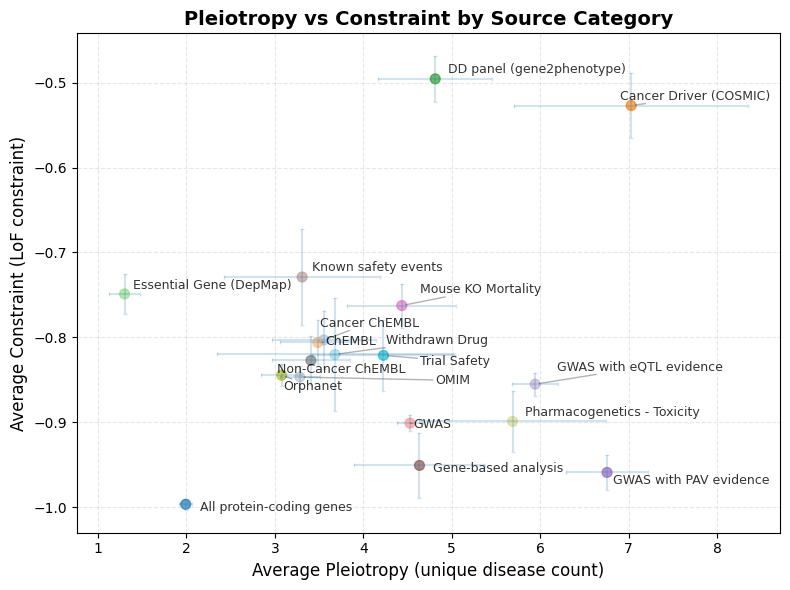

In [78]:
# First install: pip install adjustText
from adjustText import adjust_text

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each source category as a point
scatter = ax.scatter(summary_stats['pleiotropy_mean'], 
                    summary_stats['constraint_mean'],
                    s=50, alpha=0.7, c=range(len(summary_stats)), 
                    cmap='tab20')

# Add error bars
ax.errorbar(summary_stats['pleiotropy_mean'], 
           summary_stats['constraint_mean'],
           xerr=summary_stats['pleiotropy_ci'],
           yerr=summary_stats['constraint_ci'],
           fmt='none', capsize=1.5, capthick=1, alpha=0.2)

# Create text annotations
texts = []
for i, row in summary_stats.iterrows():
    txt = ax.annotate(row['source'], 
                     (row['pleiotropy_mean'], row['constraint_mean']),
                     fontsize=9, alpha=0.8)
    texts.append(txt)

# Adjust text positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6))

ax.set_xlabel('Average Pleiotropy (unique disease count)', fontsize=12)
ax.set_ylabel('Average Constraint (LoF constraint)', fontsize=12)
ax.set_title('Pleiotropy vs Constraint by Source Category', fontsize=14, fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.3)
#ax.set_xlim(3, 5)  # Set x-axis from 0 to 5
#ax.set_ylim(-1, -0.7)  # Set y-axis from 0 to 2

plt.tight_layout()
plt.show()

# Plotting - pleiotropy_combined_evidence_gwas_only

In [2]:
target=session.spark.read.csv("./data/target_with_constraints_2509.csv",header=True, inferSchema=True)
target.count()

20083

In [3]:
pleiotropy_combined_evidence = session.spark.read.csv("./data/pleiotropy_combined_evidence_gwas_only.csv",header=True, inferSchema=True)
pleiotropy_combined_evidence.count()

8285

In [4]:
pleiotropy_combined_evidence.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000196950|                   2|
+---------------+--------------------+
only showing top 1 row



In [13]:
g_p_s=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/genes_therapeutic_areas") 

In [5]:
combined_evidence=session.spark.read.csv("./data/combined_evidence_for_constrain_plot.csv", header=True, inferSchema=True)

In [6]:
combined_evidence.count()

60511

In [7]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|          hc_paralog| 4173|
|    distant_ortholog|  830|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|       selectiveGene|  930|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
+--------------------+-----+
only showing top 20 rows



In [8]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|orphanet|
+---------------+--------+
only showing top 1 row



In [45]:
gwas_genes=combined_evidence.filter(f.col("source")=="all_diseases").select("targetId").distinct()
#combined_evidence=combined_evidence.join(gwas_genes, on="targetId", how="inner")

In [46]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|          hc_paralog| 4173|
|    distant_ortholog|  830|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|       selectiveGene|  930|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
+--------------------+-----+
only showing top 20 rows



In [47]:
# Create mapping dictionary
category_mapping = {
    'all_diseases': 'GWAS',
    'cancer_ChEMBL': 'Cancer ChEMBL',
    'gene_burden': 'Gene-based analysis',
    'omim': 'OMIM',
    'cancer_driver_gene': 'Cancer Driver (COSMIC)',
    'withdrawn_drug': 'Withdrawn Drug',
    'non_cancer_ChEMBL': 'Non-Cancer ChEMBL',
    'essential_gene': 'Essential Gene (DepMap)',
    'gwas_eQTL': 'GWAS with eQTL evidence',
    'gwas_with_pav': 'GWAS with PAV evidence',
    'liable_target': 'Known safety events',
    'orphanet': 'Orphanet',
    'ChEMBL': 'ChEMBL',
    'dd_related': 'DD panel (gene2phenotype)',
    'pharmacogene': 'Pharmacogenetics - Toxicity',
    'trial_safety_concern': 'Trial Safety',
    'mouse_ko_mortality': 'Mouse KO Mortality',
    'All genes': 'All protein-coding genes'
}

# Apply the mapping
from pyspark.sql.functions import col
combined_evidence = combined_evidence.replace(category_mapping, subset=['source'])

In [48]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
+--------------------+-----+
only showing top 20 rows



In [49]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|Orphanet|
+---------------+--------+
only showing top 1 row



In [50]:
combined_evidence.count()

60511

In [51]:
g_p_s=g_p_s.withColumnRenamed("geneId","targetId")
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|       targetId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [52]:
combined_evidence = (
    combined_evidence
    .join(g_p_s.select("targetId","uniqueDiseases","pathwayCount"), on="targetId", how="left")
    .fillna(0, subset=["uniqueDiseases","pathwayCount"])
    .cache()
)

combined_evidence.count()

60511

In [53]:
combined_evidence.show(1)

+---------------+--------+--------------+------------+
|       targetId|  source|uniqueDiseases|pathwayCount|
+---------------+--------+--------------+------------+
|ENSG00000121075|Orphanet|             2|           0|
+---------------+--------+--------------+------------+
only showing top 1 row



In [54]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
+--------------------+-----+
only showing top 20 rows



In [55]:
combined_evidence = (
    combined_evidence
    .join(target.select("targetId","lof_constr"), on="targetId", how="left")
    .cache()
)

combined_evidence.count()

60511

In [56]:
combined_evidence.show(1)

+---------------+--------+--------------+------------+----------+
|       targetId|  source|uniqueDiseases|pathwayCount|lof_constr|
+---------------+--------+--------------+------------+----------+
|ENSG00000121075|Orphanet|             2|           0|    -0.379|
+---------------+--------+--------------+------------+----------+
only showing top 1 row



In [57]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
+--------------------+-----+
only showing top 20 rows



In [58]:
combined_evidence_pd=combined_evidence.toPandas()

In [59]:
combined_evidence_pd

,targetId,source,uniqueDiseases,pathwayCount,lof_constr
0,ENSG00000121075,Orphanet,2,0,-0.379
1,ENSG00000149970,Orphanet,7,7,NaN
2,ENSG00000111837,Orphanet,3,0,-0.894
3,ENSG00000184156,Orphanet,2,2,-0.458
4,ENSG00000135249,Orphanet,0,0,-0.931
...,...,...,...,...,...
60506,ENSG00000253731,hc_paralog,0,0,-0.834
60507,ENSG00000088986,distant_ortholog,0,0,-0.744
60508,ENSG00000107937,distant_ortholog,0,0,-0.405
60509,ENSG00000150316,distant_ortholog,0,0,-0.658


In [60]:
disease_genes = [row.targetId for row in gwas_genes.collect()]

In [61]:
len(disease_genes)


8285

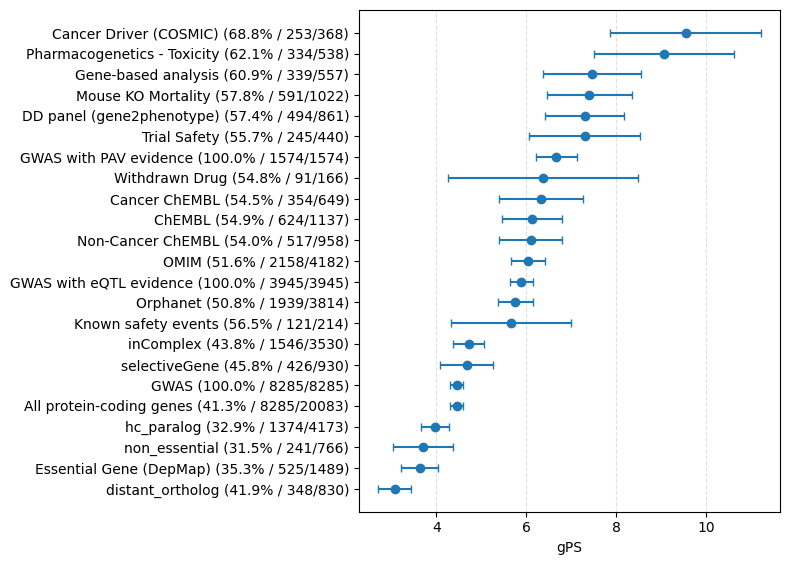

,source,N_total,N_overlap,mean_uniqueDiseases,ci95
0,Cancer Driver (COSMIC),368,253,9.541502,1.676440
1,Pharmacogenetics - Toxicity,538,334,9.059880,1.558529
2,Gene-based analysis,557,339,7.466077,1.091097
3,Mouse KO Mortality,1022,591,7.397631,0.947425
4,DD panel (gene2phenotype),861,494,7.301619,0.877399
5,Trial Safety,440,245,7.297959,1.241769
6,GWAS with PAV evidence,1574,1574,6.668996,0.453061
7,Withdrawn Drug,166,91,6.373626,2.120617
8,Cancer ChEMBL,649,354,6.319209,0.937685
9,ChEMBL,1137,624,6.126603,0.667269


In [74]:
# Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ensure disease_genes set exists
if 'disease_genes' in globals():
    disease_set = set(disease_genes)
elif 'gwas_genes' in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# keep relevant columns and deduplicate per source,targetId
df = combined_evidence_pd[['source', 'targetId', 'uniqueDiseases']].dropna(subset=['source','targetId'])
df = df.drop_duplicates(['source','targetId']).copy()

# totals per category
totals = df.groupby('source').agg(N_total=('targetId','nunique')).reset_index()

# overlap rows and stats (mean, std, count)
df['in_disease'] = df['targetId'].isin(disease_set)
overlap = (
    df[df['in_disease']]
    .groupby('source')
    .agg(N_overlap=('targetId','nunique'),
         mean_uniqueDiseases=('uniqueDiseases','mean'),
         std_uniqueDiseases=('uniqueDiseases','std'),
         n=('uniqueDiseases','count'))
    .reset_index()
)

# merge and compute SE & 95% CI
stats = totals.merge(overlap, on='source', how='left').fillna({'N_overlap':0, 'mean_uniqueDiseases':np.nan, 'std_uniqueDiseases':np.nan, 'n':0})
stats['se'] = stats['std_uniqueDiseases'] / np.sqrt(stats['n'].replace(0, np.nan))
stats['ci95'] = 1.96 * stats['se']

# add formatted label with percent and counts
stats['pct'] = 100 * stats['N_overlap'] / stats['N_total']
stats['label'] = stats.apply(lambda r: f"{r['source']} ({r['pct']:.1f}% / {int(r['N_overlap'])}/{int(r['N_total'])})", axis=1)

# order by mean desc (NaN go last)
stats_sorted = stats.sort_values('mean_uniqueDiseases', ascending=False, na_position='last').reset_index(drop=True)

# plotting horizontal
fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

# plot only categories with non-null mean
mask = stats_sorted['mean_uniqueDiseases'].notna()
ax.errorbar(stats_sorted.loc[mask,'mean_uniqueDiseases'],
             y[mask],
             xerr=stats_sorted.loc[mask,'ci95'],
             fmt='o', capsize=3, color='C0')

# optionally mark categories without overlap (no mean) with a small cross at x=0
mask_no = ~mask
if mask_no.any():
    ax.scatter([0]*mask_no.sum(), y[mask_no], marker='x', color='gray', alpha=0.6, label='no overlap')

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted['label'])
ax.invert_yaxis()
ax.set_xlabel('gPS')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# inspect resulting table
stats_sorted[['source','N_total','N_overlap','mean_uniqueDiseases','ci95']].head(100)

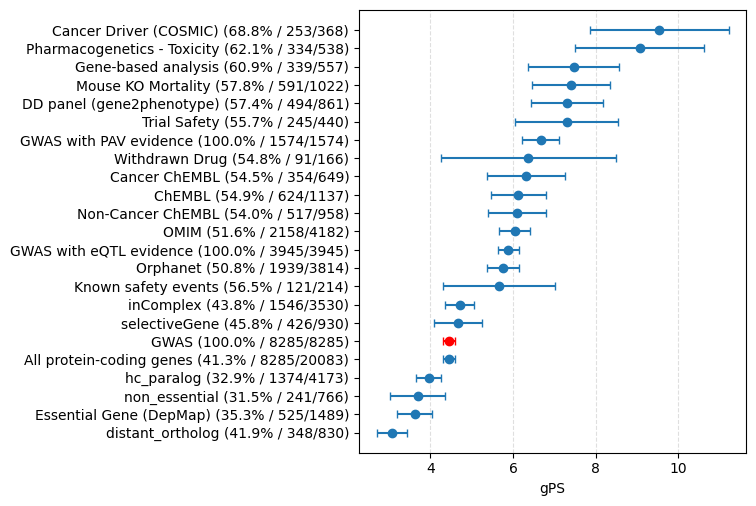

In [92]:
# ...existing code...
# plotting horizontal (highlight GWAS in red)
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted['label'])
ax.invert_yaxis()
ax.set_xlabel('gPS')
ax.grid(axis='x', linestyle='--', alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row['mean_uniqueDiseases']):
        continue
    color = 'red' if str(row['source']) == 'GWAS' else 'C0'
    ax.errorbar(row['mean_uniqueDiseases'], i,
                xerr=row['ci95'],
                fmt='o', color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted['mean_uniqueDiseases'].isna()
if no_mask.any():
    ax.scatter([0]*no_mask.sum(), y[no_mask], marker='x', color='gray', alpha=0.6, label='no overlap')

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color='red', label='GWAS')
other_patch = mpatches.Patch(color='C0', label='Other sources')
#ax.legend(handles=[gw_patch, other_patch], loc='lower right')


In [ ]:
# ...existing code...
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# build disease set
if 'disease_genes' in globals():
    disease_set = set(disease_genes)
elif 'gwas_genes' in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare dataframe
df = combined_evidence_pd[['source','targetId','uniqueDiseases']].dropna(subset=['source','targetId','uniqueDiseases']).drop_duplicates(['source','targetId']).copy()

# restrict to overlap with disease_genes
df_overlap = df[df['targetId'].isin(disease_set)].copy()

# ensure GWAS exists
if 'GWAS' not in df['source'].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# collect arrays per source
groups = {src: grp['uniqueDiseases'].values for src, grp in df_overlap.groupby('source')}

gw = groups.get('GWAS', np.array([]))

results = []
for src, vals in groups.items():
    if src == 'GWAS':
        continue
    n1 = len(gw)
    n2 = len(vals)
    mean1 = np.nanmean(gw) if n1>0 else np.nan
    mean2 = np.nanmean(vals) if n2>0 else np.nan
    std1 = np.nanstd(gw, ddof=1) if n1>1 else np.nan
    std2 = np.nanstd(vals, ddof=1) if n2>1 else np.nan
    if n1 < 2 or n2 < 2:
        tstat = np.nan
        pval = np.nan
    else:
        tstat, pval = ttest_ind(gw, vals, equal_var=False, nan_policy='omit')
    results.append({
        'source': src,
        'n_gwas': n1, 'n_source': n2,
        'mean_gwas': mean1, 'mean_source': mean2,
        'std_gwas': std1, 'std_source': std2,
        't_stat': tstat, 'p_value': pval
    })

res_df = pd.DataFrame(results).sort_values('p_value', na_position='last').reset_index(drop=True)


In [77]:
res_df

,source,n_gwas,n_source,mean_gwas,mean_source,std_gwas,std_source,t_stat,p_value
0,GWAS with eQTL evidence,8285,3945,4.448763,5.885932,6.635319,8.270875,-9.548422,1.825296e-21
1,GWAS with PAV evidence,8285,1574,4.448763,6.668996,6.635319,9.170718,-9.160281,1.302157e-19
2,OMIM,8285,2158,4.448763,6.041705,6.635319,9.021127,-7.679592,2.192034e-14
3,distant_ortholog,8285,348,4.448763,3.068966,6.635319,3.480015,6.889141,1.850816e-11
4,Orphanet,8285,1939,4.448763,5.759670,6.635319,8.689875,-6.231199,5.417461e-10
5,DD panel (gene2phenotype),8285,494,4.448763,7.301619,6.635319,9.949575,-6.290071,6.741012e-10
6,Mouse KO Mortality,8285,591,4.448763,7.397631,6.635319,11.751203,-6.032307,2.786282e-09
7,Cancer Driver (COSMIC),8285,253,4.448763,9.541502,6.635319,13.604798,-5.932640,9.644815e-09
8,Pharmacogenetics - Toxicity,8285,334,4.448763,9.059880,6.635319,14.532226,-5.774706,1.745319e-08
9,Gene-based analysis,8285,339,4.448763,7.466077,6.635319,10.249601,-5.374292,1.407379e-07


In [78]:
# ...existing code...
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# build disease set
if 'disease_genes' in globals():
    disease_set = set(disease_genes)
elif 'gwas_genes' in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare dataframe and restrict to overlap
df = combined_evidence_pd[['source','targetId','uniqueDiseases']].dropna(subset=['source','targetId','uniqueDiseases']).drop_duplicates(['source','targetId']).copy()
df_overlap = df[df['targetId'].isin(disease_set)].copy()

# ensure GWAS exists (mapped name in notebook is 'GWAS')
if 'GWAS' not in df_overlap['source'].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# collect arrays per source (drop NA)
groups = {src: grp['uniqueDiseases'].dropna().values for src, grp in df_overlap.groupby('source')}
gw = groups.get('GWAS', np.array([]))

results = []
for src, vals in groups.items():
    if src == 'GWAS':
        continue
    n_gw = len(gw)
    n_src = len(vals)
    mean_gw = np.nanmean(gw) if n_gw>0 else np.nan
    mean_src = np.nanmean(vals) if n_src>0 else np.nan
    std_gw = np.nanstd(gw, ddof=1) if n_gw>1 else np.nan
    std_src = np.nanstd(vals, ddof=1) if n_src>1 else np.nan

    if n_gw < 2 or n_src < 2:
        tstat = np.nan
        pval = np.nan
    else:
        # Student's t-test (assume equal variances)
        tstat, pval = ttest_ind(gw, vals, equal_var=True, nan_policy='omit')

    results.append({
        'source': src,
        'n_gwas': n_gw, 'n_source': n_src,
        'mean_gwas': mean_gw, 'mean_source': mean_src,
        'std_gwas': std_gw, 'std_source': std_src,
        't_stat': tstat, 'p_value': pval
    })

res_df = pd.DataFrame(results).sort_values('p_value', na_position='last').reset_index(drop=True)


In [79]:
res_df

,source,n_gwas,n_source,mean_gwas,mean_source,std_gwas,std_source,t_stat,p_value
0,Pharmacogenetics - Toxicity,8285,334,4.448763,9.059880,6.635319,14.532226,-11.628041,5.056532e-31
1,Cancer Driver (COSMIC),8285,253,4.448763,9.541502,6.635319,13.604798,-11.494570,2.348097e-30
2,GWAS with PAV evidence,8285,1574,4.448763,6.668996,6.635319,9.170718,-11.371506,8.885369e-30
3,GWAS with eQTL evidence,8285,3945,4.448763,5.885932,6.635319,8.270875,-10.313798,7.715845e-25
4,Mouse KO Mortality,8285,591,4.448763,7.397631,6.635319,11.751203,-9.767493,2.013276e-22
5,OMIM,8285,2158,4.448763,6.041705,6.635319,9.021127,-9.162803,6.004806e-20
6,DD panel (gene2phenotype),8285,494,4.448763,7.301619,6.635319,9.949575,-8.974039,3.450078e-19
7,Gene-based analysis,8285,339,4.448763,7.466077,6.635319,10.249601,-7.992091,1.497910e-15
8,Orphanet,8285,1939,4.448763,5.759670,6.635319,8.689875,-7.348938,2.150672e-13
9,Trial Safety,8285,245,4.448763,7.297959,6.635319,9.916712,-6.510030,7.937853e-11


In [83]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# build disease set
if 'disease_genes' in globals():
    disease_set = set(disease_genes)
elif 'gwas_genes' in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare deduplicated df (one row per source,targetId)
df = combined_evidence_pd[['source','targetId','uniqueDiseases']].dropna(subset=['source','targetId','uniqueDiseases']).drop_duplicates(['source','targetId']).copy()

# restrict to genes in disease_set (overlap only)
df_overlap = df[df['targetId'].isin(disease_set)].copy()

# mapping targetId -> measurement (use a single value per target)
vals_by_target = df_overlap.drop_duplicates('targetId').set_index('targetId')['uniqueDiseases']

# universe of ids to compare against
universe_ids = vals_by_target.index.values

# ensure GWAS present (name used in notebook = 'GWAS')
if 'GWAS' not in df_overlap['source'].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

results = []
sources = sorted(df_overlap['source'].unique())
for src in sources:
    if src == 'GWAS':
        continue
    # subset ids belonging to this source (in the overlap)
    subset_ids = np.unique(df_overlap.loc[df_overlap['source'] == src, 'targetId'].values)
    # complement = all universe ids minus subset ids
    complement_ids = np.setdiff1d(universe_ids, subset_ids, assume_unique=True)

    # get numeric arrays of the measurement (drop any missing)
    subset_vals = vals_by_target.reindex(subset_ids).dropna().values
    complement_vals = vals_by_target.reindex(complement_ids).dropna().values

    n_sub = len(subset_vals)
    n_cmp = len(complement_vals)
    mean_sub = np.nanmean(subset_vals) if n_sub>0 else np.nan
    mean_cmp = np.nanmean(complement_vals) if n_cmp>0 else np.nan
    std_sub = np.nanstd(subset_vals, ddof=1) if n_sub>1 else np.nan
    std_cmp = np.nanstd(complement_vals, ddof=1) if n_cmp>1 else np.nan

    if n_sub < 2 or n_cmp < 2:
        tstat = np.nan; pval = np.nan
    else:
        # Student's t-test (assume equal variances)
        tstat, pval = ttest_ind(subset_vals, complement_vals, equal_var=False, nan_policy='omit')

    results.append({
        'source': src,
        'n_subset': n_sub, 'n_complement': n_cmp,
        'mean_subset': mean_sub, 'mean_complement': mean_cmp,
        'std_subset': std_sub, 'std_complement': std_cmp,
        't_stat': tstat, 'p_value': pval
    })

res_df = pd.DataFrame(results).sort_values('p_value', na_position='last').reset_index(drop=True)



In [84]:
res_df

,source,n_subset,n_complement,mean_subset,mean_complement,std_subset,std_complement,t_stat,p_value
0,GWAS with eQTL evidence,3945,4340,5.885932,3.142396,8.270875,4.276942,18.686838,1.036205e-75
1,GWAS with PAV evidence,1574,6711,6.668996,3.928029,9.170718,5.762982,11.344055,6.787398e-29
2,OMIM,2158,6127,6.041705,3.887710,9.021127,5.447352,10.441745,4.705340e-25
3,Orphanet,1939,6346,5.759670,4.048219,8.689875,5.807894,8.135002,6.429972e-16
4,distant_ortholog,348,7937,3.068966,4.509260,3.480015,6.733604,-7.155738,3.219790e-12
5,DD panel (gene2phenotype),494,7791,7.301619,4.267873,9.949575,6.325001,6.691818,5.730514e-11
6,Mouse KO Mortality,591,7694,7.397631,4.222251,11.751203,6.008313,6.504140,1.621304e-10
7,Cancer Driver (COSMIC),253,8032,9.541502,4.288347,13.604798,6.226059,6.121539,3.473766e-09
8,Pharmacogenetics - Toxicity,334,7951,9.059880,4.255062,14.532226,6.008367,6.020940,4.522295e-09
9,Gene-based analysis,339,7946,7.466077,4.320035,10.249601,6.405602,5.604912,4.233999e-08


In [87]:
import numpy as np
import pandas as pd

# build disease set (same as before)
if 'disease_genes' in globals():
    disease_set = set(disease_genes)
elif 'gwas_genes' in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare deduplicated df (one row per source,targetId)
df = combined_evidence_pd[['source','targetId','uniqueDiseases']].dropna(subset=['source','targetId','uniqueDiseases']).drop_duplicates(['source','targetId']).copy()

# restrict to genes in disease_set (overlap only)
df_overlap = df[df['targetId'].isin(disease_set)].copy()

# mapping targetId -> measurement (one value per target)
vals_by_target = df_overlap.drop_duplicates('targetId').set_index('targetId')['uniqueDiseases'].dropna()
universe_vals = vals_by_target.values  # x in your example

# ensure GWAS present (name used in notebook = 'GWAS')
if 'GWAS' not in df_overlap['source'].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# permutation test parameters
n_perm = 20000
rng = np.random.default_rng(42)

results = []
sources = sorted(df_overlap['source'].unique())
for src in sources:
    if src == 'GWAS':
        continue

    # ids in this source (within the overlap)
    subset_ids = np.unique(df_overlap.loc[df_overlap['source'] == src, 'targetId'].values)
    subset_vals = vals_by_target.reindex(subset_ids).dropna().values

    n_sub = len(subset_vals)
    n_univ = len(universe_vals)

    if n_sub < 1 or n_sub > n_univ:
        # cannot perform permutation
        results.append({
            'source': src,
            'n_subset': n_sub,
            'mean_subset': np.nan,
            'mean_universe': np.nan,
            'obs_diff': np.nan,
            'p_value_perm': np.nan,
            'perm_mean': np.nan,
            'perm_std': np.nan
        })
        continue

    mean_univ = universe_vals.mean()
    mean_sub = subset_vals.mean()
    obs_diff = mean_sub - mean_univ

    # perform permutations: sample subsets of size n_sub from universe_vals without replacement
    perm_diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        sample = rng.choice(universe_vals, size=n_sub, replace=False)
        perm_diffs[i] = sample.mean() - mean_univ

    # two-sided empirical p-value
    p_val = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

    results.append({
        'source': src,
        'n_subset': n_sub,
        'n_universe': n_univ,
        'mean_subset': mean_sub,
        'mean_universe': mean_univ,
        'obs_diff': obs_diff,
        'p_value_perm': p_val,
        'perm_mean': perm_diffs.mean(),
        'perm_std': perm_diffs.std(ddof=1)
    })

res_df = pd.DataFrame(results).sort_values('p_value_perm', na_position='last').reset_index(drop=True)


In [86]:
res_df

,source,n_subset,n_universe,mean_subset,mean_universe,obs_diff,p_value_perm,perm_mean,perm_std
0,Mouse KO Mortality,591,8285,7.397631,4.448763,2.948868,0.0000,0.001493,0.262646
1,Pharmacogenetics - Toxicity,334,8285,9.059880,4.448763,4.611117,0.0000,-0.005005,0.360929
2,Orphanet,1939,8285,5.759670,4.448763,1.310907,0.0000,-0.000291,0.131257
3,OMIM,2158,8285,6.041705,4.448763,1.592942,0.0000,0.000573,0.123479
4,Non-Cancer ChEMBL,517,8285,6.096712,4.448763,1.647949,0.0000,-0.001702,0.282613
5,Trial Safety,245,8285,7.297959,4.448763,2.849196,0.0000,0.003252,0.420273
6,GWAS with eQTL evidence,3945,8285,5.885932,4.448763,1.437169,0.0000,0.000066,0.076816
7,Gene-based analysis,339,8285,7.466077,4.448763,3.017314,0.0000,-0.001324,0.357005
8,DD panel (gene2phenotype),494,8285,7.301619,4.448763,2.852857,0.0000,-0.005920,0.288565
9,ChEMBL,624,8285,6.126603,4.448763,1.677840,0.0000,0.001092,0.257838


In [90]:
# ...existing code...
# Benjamini-Hochberg FDR on permutation p-values (fixed)
p = res_df['p_value_perm'].to_numpy(dtype=float)
mask = ~np.isnan(p)
adj_full = np.full_like(p, np.nan, dtype=float)

if mask.sum() > 0:
    pvals = p[mask]
    m = pvals.size
    order = np.argsort(pvals)                     # indices that sort pvals ascending
    sorted_p = pvals[order]
    ranks = np.arange(1, m + 1)
    q = sorted_p * m / ranks                      # raw BH adjusted (not yet monotonic)
    # enforce monotonicity: take cumulative minimum from largest rank to smallest
    q_adj = np.minimum.accumulate(q[::-1])[::-1]
    q_adj = np.clip(q_adj, 0, 1)
    # map adjusted back to the masked original order
    adj_masked = np.empty_like(q_adj)
    adj_masked[order] = q_adj
    adj_full[mask] = adj_masked

res_df['p_adj_bh'] = adj_full
# ...existing code...

In [91]:
res_df

,source,n_subset,n_universe,mean_subset,mean_universe,obs_diff,p_value_perm,perm_mean,perm_std,p_adj_bh
0,Mouse KO Mortality,591,8285,7.397631,4.448763,2.948868,0.00000,-0.001362,0.262120,0.000000
1,Pharmacogenetics - Toxicity,334,8285,9.059880,4.448763,4.611117,0.00000,0.002259,0.354161,0.000000
2,Orphanet,1939,8285,5.759670,4.448763,1.310907,0.00000,-0.000230,0.130892,0.000000
3,OMIM,2158,8285,6.041705,4.448763,1.592942,0.00000,-0.000807,0.122991,0.000000
4,Non-Cancer ChEMBL,517,8285,6.096712,4.448763,1.647949,0.00000,0.001658,0.281174,0.000000
5,Trial Safety,245,8285,7.297959,4.448763,2.849196,0.00000,-0.001306,0.417593,0.000000
6,GWAS with eQTL evidence,3945,8285,5.885932,4.448763,1.437169,0.00000,0.000032,0.076399,0.000000
7,Gene-based analysis,339,8285,7.466077,4.448763,3.017314,0.00000,-0.002772,0.351619,0.000000
8,DD panel (gene2phenotype),494,8285,7.301619,4.448763,2.852857,0.00000,-0.000898,0.290479,0.000000
9,ChEMBL,624,8285,6.126603,4.448763,1.677840,0.00000,-0.000325,0.256454,0.000000


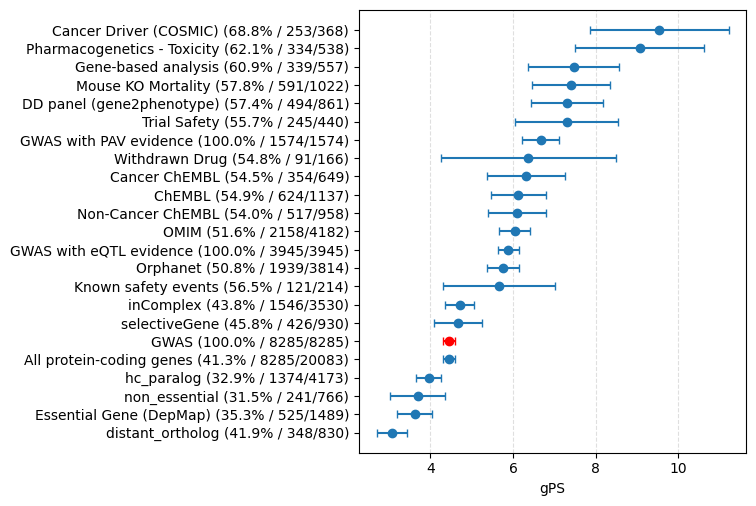

In [93]:
# ...existing code...
# plotting horizontal (highlight GWAS in red)
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted['label'])
ax.invert_yaxis()
ax.set_xlabel('gPS')
ax.grid(axis='x', linestyle='--', alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row['mean_uniqueDiseases']):
        continue
    color = 'red' if str(row['source']) == 'GWAS' else 'C0'
    ax.errorbar(row['mean_uniqueDiseases'], i,
                xerr=row['ci95'],
                fmt='o', color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted['mean_uniqueDiseases'].isna()
if no_mask.any():
    ax.scatter([0]*no_mask.sum(), y[no_mask], marker='x', color='gray', alpha=0.6, label='no overlap')

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color='red', label='GWAS')
other_patch = mpatches.Patch(color='C0', label='Other sources')
#ax.legend(handles=[gw_patch, other_patch], loc='lower right')


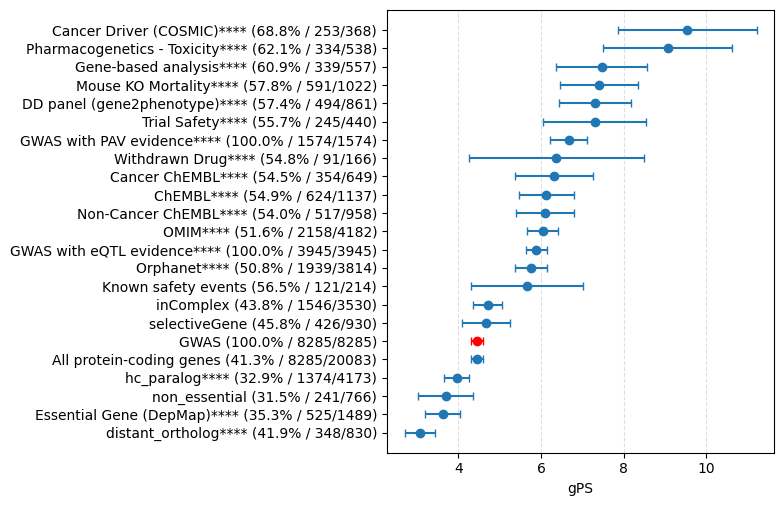

25/11/07 22:40:15 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 989191 ms exceeds timeout 120000 ms
25/11/07 22:40:15 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/07 22:41:09 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [95]:
# ...existing code...
import matplotlib.patches as mpatches

# determine significant sources (BH-adjusted p <= 0.05) — keep robust if res_df missing
if 'res_df' in globals():
    sig_sources = set(res_df.loc[res_df['p_adj_bh'] <= 0.05, 'source'].dropna().astype(str))
else:
    sig_sources = set()

# add '*' to the category name in the label if significant
def add_star_to_label(label: str, source: str) -> str:
    try:
        s = str(source)
        if s in sig_sources:
            return label.replace(s, f"{s}***")
    except Exception:
        pass
    return label

stats_sorted['label'] = stats_sorted.apply(lambda r: add_star_to_label(r['label'], r['source']), axis=1)

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted['label'])
ax.invert_yaxis()
ax.set_xlabel('gPS')
ax.grid(axis='x', linestyle='--', alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row['mean_uniqueDiseases']):
        continue
    color = 'red' if str(row['source']) == 'GWAS' else 'C0'
    ax.errorbar(row['mean_uniqueDiseases'], i,
                xerr=row['ci95'],
                fmt='o', color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted['mean_uniqueDiseases'].isna()
if no_mask.any():
    ax.scatter([0]*no_mask.sum(), y[no_mask], marker='x', color='gray', alpha=0.6, label='no overlap')

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color='red', label='GWAS')
other_patch = mpatches.Patch(color='C0', label='Other sources')
#ax.legend(handles=[gw_patch, other_patch], loc='lower right')
# ...existing code...

In [29]:
combined_evidence_pd = combined_evidence_pd.dropna(subset=['lof_constr'])

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate summary statistics by source
summary_stats = combined_evidence_pd.groupby('source').agg({
    'uniqueDiseases': ['mean', 'std', 'count'],
    'lof_constr': ['mean', 'std', 'count']
}).reset_index()

# Flatten column names
summary_stats.columns = ['source', 'pleiotropy_mean', 'pleiotropy_std', 'pleiotropy_count',
                         'constraint_mean', 'constraint_std', 'constraint_count']

# Calculate 95% CI (1.96 * SE)
summary_stats['pleiotropy_se'] = summary_stats['pleiotropy_std'] / np.sqrt(summary_stats['pleiotropy_count'])
summary_stats['pleiotropy_ci'] = 1.96 * summary_stats['pleiotropy_se']

summary_stats['constraint_se'] = summary_stats['constraint_std'] / np.sqrt(summary_stats['constraint_count'])
summary_stats['constraint_ci'] = 1.96 * summary_stats['constraint_se']


In [31]:
to_exclude=[
'Gene-based analysis',
'OMIM',
'Orphanet',
'ChEMBL',
'All protein-coding genes']

In [32]:
summary_stats = summary_stats[~summary_stats['source'].isin(to_exclude)]

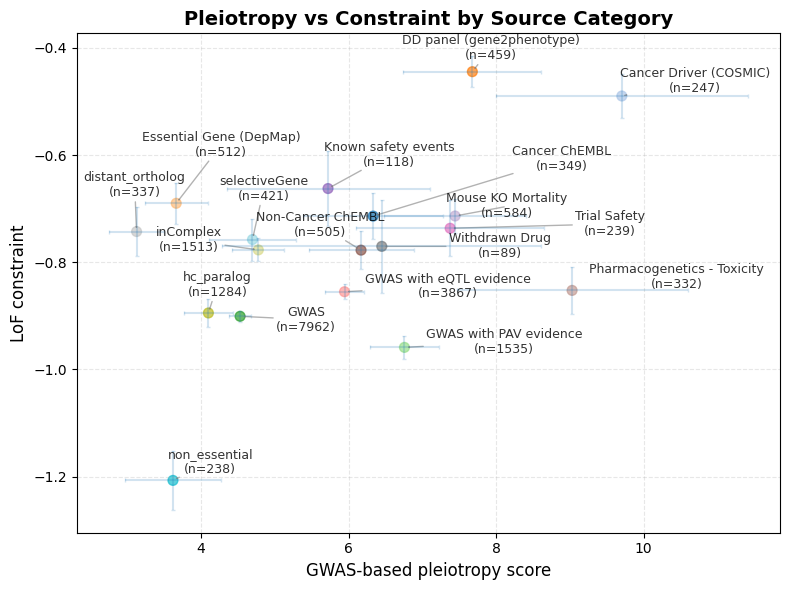

In [33]:
# First install: pip install adjustText
from adjustText import adjust_text

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each source category as a point
scatter = ax.scatter(summary_stats['pleiotropy_mean'], 
                    summary_stats['constraint_mean'],
                    s=50, alpha=0.7, c=range(len(summary_stats)), 
                    cmap='tab20')

# Add error bars
ax.errorbar(summary_stats['pleiotropy_mean'], 
           summary_stats['constraint_mean'],
           xerr=summary_stats['pleiotropy_ci'],
           yerr=summary_stats['constraint_ci'],
           fmt='none', capsize=1.5, capthick=1, alpha=0.2)

# Create text annotations with gene counts
texts = []
for i, row in summary_stats.iterrows():
    # Format the label to include source name and gene count
    label = f"{row['source']}\n(n={int(row['pleiotropy_count'])})"
    txt = ax.annotate(label, 
                     (row['pleiotropy_mean'], row['constraint_mean']),
                     fontsize=9, alpha=0.8, ha='center')
    texts.append(txt)

# Adjust text positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6))

ax.set_xlabel('GWAS-based pleiotropy score', fontsize=12)
ax.set_ylabel('LoF constraint', fontsize=12)
ax.set_title('Pleiotropy vs Constraint by Source Category', fontsize=14, fontweight='bold')
ax.grid(True, linestyle="--", alpha=0.3)
#ax.set_xlim(3, 5)  # Set x-axis from 0 to 5
#ax.set_ylim(-1, -0.7)  # Set y-axis from 0 to 2

plt.tight_layout()
plt.show()

In [34]:
combined_evidence_pd_gwas=combined_evidence_pd[combined_evidence_pd["source"]=="GWAS"]

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create 10 bins for lof_constr
combined_evidence_pd_gwas['lof_constr_bins'] = pd.cut(
    combined_evidence_pd_gwas['lof_constr'], 
    bins=30, 
    labels=False
)

# Calculate bin statistics
bin_stats = combined_evidence_pd_gwas.groupby('lof_constr_bins').agg({
    'unique_disease_count': ['mean', 'std', 'count'],
    'lof_constr': ['min', 'max', 'mean']
}).reset_index()

# Flatten column names
bin_stats.columns = [
    'bin_number', 
    'disease_mean', 'disease_std', 'disease_count',
    'lof_min', 'lof_max', 'lof_mean'
]

# Calculate 95% CI
bin_stats['disease_se'] = bin_stats['disease_std'] / np.sqrt(bin_stats['disease_count'])
bin_stats['disease_ci_lower'] = bin_stats['disease_mean'] - 1.96 * bin_stats['disease_se']
bin_stats['disease_ci_upper'] = bin_stats['disease_mean'] + 1.96 * bin_stats['disease_se']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean with error bars
ax.errorbar(bin_stats['lof_mean'], bin_stats['disease_mean'],
            yerr=[bin_stats['disease_mean'] - bin_stats['disease_ci_lower'],
                  bin_stats['disease_ci_upper'] - bin_stats['disease_mean']],
            fmt='o-', capsize=5, capthick=2, linewidth=2, markersize=6,
            color='blue', ecolor='lightblue')

# Add sample sizes as text
for i, row in bin_stats.iterrows():
    ax.text(row['lof_mean'], row['disease_mean'] + 0.1, 
            f'n={int(row["disease_count"])}',
            ha='center', va='bottom', fontsize=9, alpha=0.7)

# Customize the plot
ax.set_xlabel('LoF Constraint (bin centers)', fontsize=12)
ax.set_ylabel('Mean Unique Disease Count', fontsize=12)
ax.set_title('Pleiotropy vs LoF Constraint\n(Binned Analysis with 95% CI)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print bin statistics
print("Bin statistics:")
print(bin_stats[['bin_number', 'lof_min', 'lof_max', 'disease_mean', 'disease_count']])

/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_56682/627308123.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



KeyError: "Column(s) ['unique_disease_count'] do not exist"

In [198]:
combined_evidence_pd[combined_evidence_pd["source"]=="Essential Gene (DepMap)"]["targetId"].to_csv("./data/for_GSEA_essential_genes.txt", index=False, header=False)